In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Data Preparation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    'C:/Users/Kotes/OneDrive/Desktop/seeds',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    'C:/Users/Kotes/OneDrive/Desktop/seeds',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Model Architecture
base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = Flatten()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(8, activation='softmax')(x)  # 8 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=5)

# Training
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)


Found 1120 images belonging to 8 classes.
Found 280 images belonging to 8 classes.


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5888 - loss: 1.1522

35/35 ━━━━━━━━━━━━━━━━━━━━ 254s 7s/step - accuracy: 0.5936 - loss: 1.1384 - val_accuracy: 0.9357 - val_loss: 0.1667
Epoch 2/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9221 - loss: 0.2169

35/35 ━━━━━━━━━━━━━━━━━━━━ 220s 6s/step - accuracy: 0.9223 - loss: 0.2167 - val_accuracy: 0.9929 - val_loss: 0.0930
Epoch 3/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 149s 4s/step - accuracy: 0.9347 - loss: 0.1623 - val_accuracy: 0.9571 - val_loss: 0.1346
Epoch 4/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 151s 4s/step - accuracy: 0.9516 - loss: 0.1438 - val_accuracy: 0.9786 - val_loss: 0.0866
Epoch 5/5
35/35 ━━━━━━━━━━━━━━━━━━━━ 139s 4s/step - accuracy: 0.9693 - loss: 0.0942 - val_accuracy: 0.9750 - val_loss: 0.0656


In [6]:

# Evaluation
test_generator = ImageDataGenerator(rescale=1./255).flow_from_directory(
    'C:/Users/Kotes/OneDrive/Desktop/seeds',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

y_true = test_generator.classes
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)



Found 1400 images belonging to 8 classes.
44/44 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step


Classification Report:
                    precision    recall  f1-score   support

             Wheat       1.00      1.00      1.00       100
        black gram       0.00      0.00      0.00         0
         chickpeas       0.68      1.00      0.81       100
              corn       1.00      1.00      1.00       500
            cowpea       1.00      0.52      0.68       100
       moong beans       1.00      1.00      1.00       100
          soyabean       1.00      1.00      1.00       400
white kidney beans       1.00      1.00      1.00       100

          accuracy                           0.97      1400
         macro avg       0.83      0.81      0.81      1400
      weighted avg       0.98      0.97      0.96      1400



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\ProgramData\anaconda3\Lib\site-package

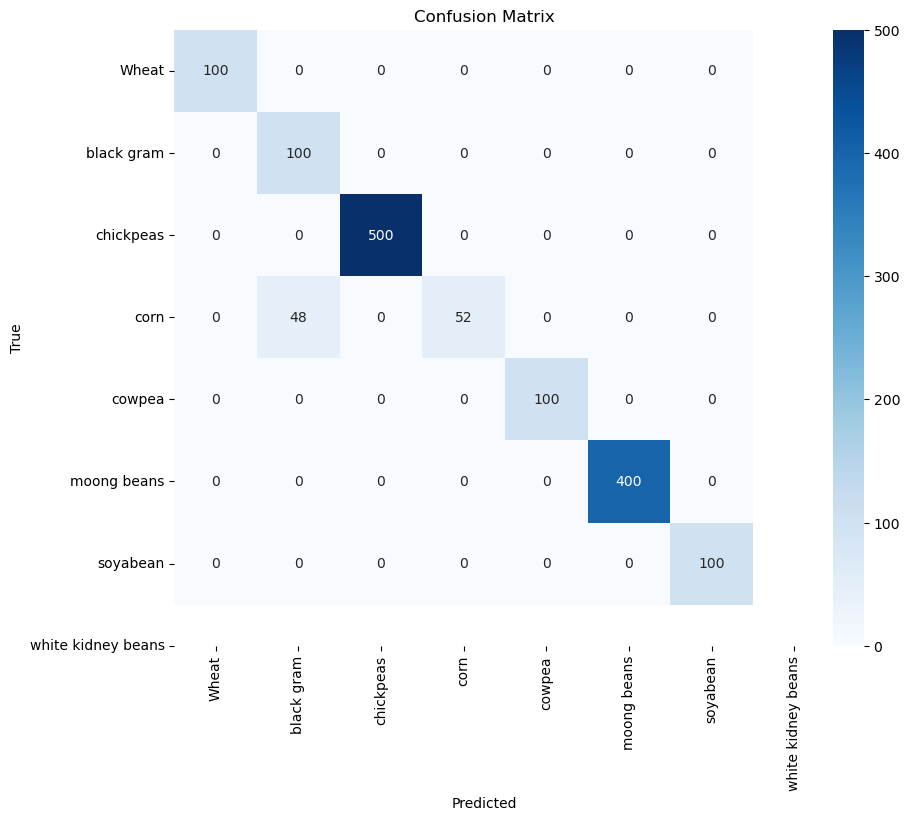

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1183: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


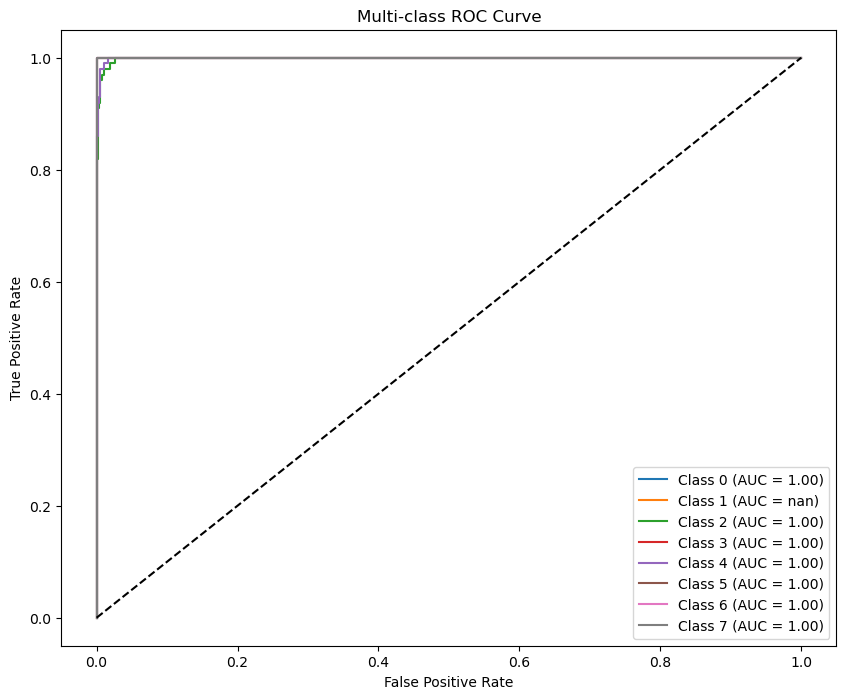

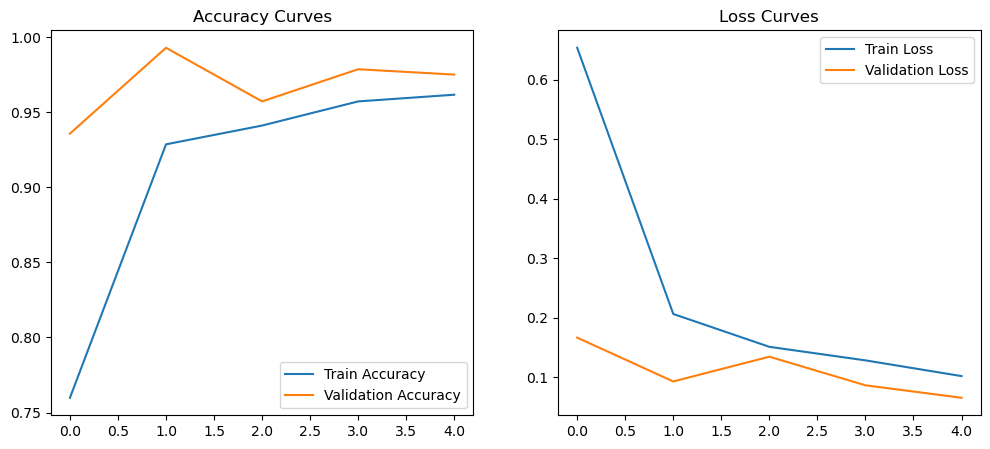

In [7]:



# Classification Report
print("Classification Report:")
num_classes = len(train_generator.class_indices)
print(classification_report(y_true, y_pred_classes, labels=list(range(num_classes)), target_names=list(train_generator.class_indices.keys())[:num_classes]))


# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ROC Curve
y_test_bin = label_binarize(y_true, classes=np.arange(8))
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(8):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(8):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Training History Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.legend()
plt.show()

# Sample Prediction
def predict_seed(image_path):
    img = tf.keras.preprocessing.image.load_img(
        image_path, target_size=(224, 224)
    )
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    prediction = model.predict(img_array)
    class_idx = np.argmax(prediction)
    confidence = np.max(prediction)
    
    plt.imshow(img)
    plt.title(f"Predicted: {list(train_generator.class_indices.keys())[class_idx]}\nConfidence: {confidence:.2f}")
    plt.axis('off')
    plt.show()

# Usage: predict_seed('path/to/your/seed_image.jpg')


Final Validation Accuracy: 97.50%
44/44 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.9775 - loss: 0.0532
Test Accuracy: 96.57%

Epoch-wise Metrics:
Epoch     Train Acc   Val Acc     
1         75.98     %93.57     %
2         92.86     %99.29     %
3         94.11     %95.71     %
4         95.71     %97.86     %
5         96.16     %97.50     %


44/44 ━━━━━━━━━━━━━━━━━━━━ 129s 3s/step - accuracy: 0.9676 - loss: 0.1296

Best Model Test Accuracy: 96.79%


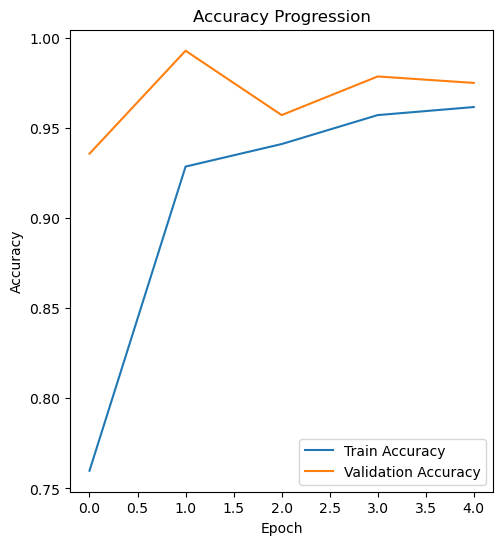

In [8]:
# After model training (from previous code)
# ================================================

# 1. Get final validation accuracy from training history
val_acc = history.history['val_accuracy'][-1] * 100  # Last epoch's validation accuracy
print(f"Final Validation Accuracy: {val_acc:.2f}%")

# 2. Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# 3. Plot accuracy progression (from search result [1])
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Progression')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

# 4. Print epoch-wise metrics table (from search result [3])
print("\nEpoch-wise Metrics:")
print(f"{'Epoch':<10}{'Train Acc':<12}{'Val Acc':<12}")
for epoch, (train_acc, val_acc) in enumerate(zip(history.history['accuracy'], 
                                                history.history['val_accuracy'])):
    print(f"{epoch + 1:<10}{train_acc*100:<10.2f}%{val_acc*100:<10.2f}%")

# 5. Best model evaluation (from search result [8])
# Load best saved model
from tensorflow.keras.models import load_model
best_model = load_model('best_model.h5')
_, best_test_acc = best_model.evaluate(test_generator)
print(f"\nBest Model Test Accuracy: {best_test_acc * 100:.2f}%")
